# Q14. Can adapting two active mixer blocks improve Evo2 fine-tuning?

Test additional adapter capacity by extending block-30 LoRA to **blocks 29 and 30**. Initialize from the strongest frozen classifier completed by [Q12](Q12-lora-improvement.ipynb) or [Q13](Q13-lora-optimization.ipynb), hold that classifier fixed, and retain the same magnitude-aware features and matched frozen controls. Two learning-rate arms test this hypothesis under a one-hour budget on the prepared H100.

Use **Gamow** and run every cell in order. Prerequisites are completed Q11/Q12/Q13 artifacts, the checksum-pinned Savanna Evo2 7B base checkpoint and the prepared BioNeMo runtime. [Protocol and reporting](src/q14.py) · [Adapter placement](src/q14_adapters.py) · [GPU workflow](src/q14_backend.py) · [Setup](../README.md#setup).

In [1]:
from src import q14

## Fixed inputs and feature provenance

Retain Q1’s frozen 6 July 2026 ClinVar missense partitions, all inherited eligibility and gene/component/sequence separation checks, and exactly Q12’s authorized **24,576 training variants** and uniform seed-42 **2,048 validation variants**. The full partitions contain 46,888 and 17,927 variants respectively. Validation remains a development set.

Reuse only checksum-verified Q12 frozen feature caches: 512-base canonical paired strand, final-block mean pooling, unit-RMS reference and allele-difference vectors, plus log difference RMS and log relative RMS (**8,194 features**). Retain the selected checkpoint’s training-only standardization. Freeze sources, parent results, cache manifest and exact memberships before training; validation labels never enter gradients or preprocessing. Preserve the exact implementation in each attempt’s source snapshot.

In [2]:
protocol = q14.prepare()

Frozen 24,576/46,888 training rows and 2,048/17,927 validation rows; verified Q12 features and fixed q12_control classifier will be reused.


## Fix the strongest classifier and extend adapter placement

Compare the completed **best frozen controls** from Q12 and Q13 by sampled AUROC, then AP; retain Q12 on an exact tie. Freeze the winning source, full checkpoint path and checksum before training. Load its **control head and mean/scale**, using Q12’s verified training class weights. Q14 does not refit the classifier or require a new convergence test. The parent’s selected adapter head is never substituted for its frozen control.

Initialize both arms from that same head and the original frozen backbone. Attach distinct rank-8/alpha-16 adapters to **dense_projection** and **dense** in each of **blocks 29 and 30**: four target modules, Xavier A, zero B, dropout **0**. Verify unique adapter tensors, exact target coverage, zero-output equivalence and actual updates before interpreting scores. Keep the original backbone weights frozen.

Try adapter peak learning rates **3e-5 and 1e-4**, with **32-step warmup** and cosine decay to **10%**. Head learning rate **0**, adapter weight decay **0.01**, seed **42**, batch **32**, at most **512 updates per arm**. Keep BF16 backbone/adapters and FP32 head and optimizer master weights.

## Matched controls, stopping and integrity

Both arms begin with the same fixed classifier and receive the same training examples and batch order. Optimize adapters with balanced binary cross entropy only; explicit head L2 strength is **0** because classifier weights remain fixed. Clip adapter gradient norms at **1.0**. Classifier parameters have gradients disabled and never enter an optimizer. The matched control applies the identical fixed classifier to original frozen features at every checkpoint. Record actual adapter changes and check that classifier weights and the scaler remain unchanged, and reproduce the inherited control scores before training, so any prediction improvement must come from the adapters. Retain **step 0**, then monitor after **256** and **512** updates, or when the deadline requires final validation and reporting. Save optimizer/master/RNG/cursor state every **32 updates**, with the original run deadline recorded. These states are retained for inspection; automatic checkpoint resumption is not implemented. A fresh runner archives the preceding attempt and starts a new experiment from zero-output adapters.

Use one GPU process. Reserve a sampled evaluation, a **64-variant** checkpoint reload check and three minutes for reporting under the one-hour budget; interrupted and completed attempts remain inspectable. Verify finite updates and unchanged original backbone tensors. Erase learned tensors and reload the selected checkpoint to reproduce predictions.

Choose LoRA only when it improves AUROC by **at least 0.005** without decreasing AP against the strongest frozen classifier, including Q12’s and Q13’s controls and the initial fitted head. Retain the best LoRA checkpoint together with the control at its exact update count for paired inference. This experiment tests adapter placement and learning rate without claiming that additional capacity necessarily helps.

In [3]:
result = q14.run_experiment()

Explore: notebooks/results/q14/explore.log


## Sampled development results

Report AUROC/AP with **1,000 whole-component bootstrap draws**, seed **42**, and the paired LoRA-minus-control effect. Intervals do not correct repeated validation, regularization, learning-rate or checkpoint selection. These results cannot establish performance on an untouched holdout and must stay separate from the full-cohort README benchmark.

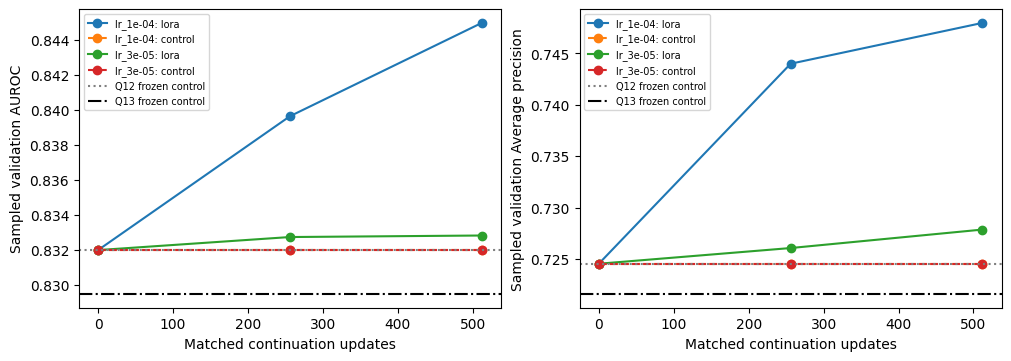

| Model | AUROC (95% interval) | AP (95% interval) |
| --- | ---: | ---: |
| Q12 frozen control | 0.832 [0.812, 0.853] | 0.725 [0.681, 0.771] |
| Q13 frozen control | 0.829 [0.808, 0.850] | 0.722 [0.676, 0.766] |
| Matched frozen control | 0.832 [0.812, 0.853] | 0.725 [0.681, 0.771] |
| Best Q14 frozen control | 0.832 [0.812, 0.853] | 0.725 [0.681, 0.771] |
| Best Q14 LoRA | 0.845 [0.825, 0.865] | 0.748 [0.702, 0.791] |
| Selected model | 0.845 [0.825, 0.865] | 0.748 [0.702, 0.791] |

In [4]:
q14.show_results()

## Conclusion

The conclusion is computed from the completed run and its frozen promotion rule.

In [5]:
q14.show_conclusion()

**Conclusion.** LoRA met the prespecified promotion rule. Selected **lora**: AUROC **0.845**, AP **0.748**, on **2,048 development validation variants**. Best adapter trial: **lr_1e-04**, checkpoint **512 updates**. LoRA minus its matched control: AUROC **+0.0130** (95% component interval **[+0.0050, +0.0206]**). Promotion requires at least **0.005 AUROC** improvement and no AP reduction against the strongest Q14, Q13 or Q12 frozen control, including the initial fitted head. The measured experiment took **42.9 minutes**; within the one-hour target. These sampled results do not replace the complete-cohort benchmark. User-authorized exploratory subsets: the same 24,576 training variants and 2,048 validation variants as Q12/Q13. Previous validation selected the inherited head and its regularization; Q14 validation selects the strongest frozen starting classifier, adapter learning rate and checkpoints. Repeated development selection and bootstrap intervals do not establish performance on an untouched holdout. The paired effect compares LoRA with its fixed classifier on original frozen features after the same monitored examples and adapter update count; promotion also requires improvement over the strongest Q14, Q13 or Q12 frozen control. No clinical validation; pretraining exposure, homology and shared-patient overlap remain unresolved.